In [1]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
Python executable: c:\DATA_SCIENCE\PORTAFOLIO\VibeSig\.venv\Scripts\python.exe


In [2]:
from datasets import load_dataset
import pandas as pd

c:\DATA_SCIENCE\PORTAFOLIO\VibeSig\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_dataset("Yelp/yelp_review_full")

c:\DATA_SCIENCE\PORTAFOLIO\VibeSig\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MARE\.cache\huggingface\hub\datasets--Yelp--yelp_review_full. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\DATA_SCIENCE\PORTAFOLIO\VibeSig\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarn

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

In [5]:
dataset["train"][0]

{'label': 4,
 'text': "dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) which my parents have explained to me is very important in case something happens and you need surgery; and you can get referrals to see specialists without having to see him first.  really, what more do you need?  i'm sitting here trying to think of any complaints i have about him, but i'm really drawing a blank."}

In [6]:
dataset["train"].features["label"]

ClassLabel(names=['1 star', '2 star', '3 stars', '4 stars', '5 stars'])

In [7]:
from collections import Counter

Counter(dataset["train"]["label"])

Counter({4: 130000, 1: 130000, 3: 130000, 0: 130000, 2: 130000})

In [8]:
samples = []

for label in range(5):
    subset = dataset["train"].filter(lambda x: x["label"] == label)
    subset = subset.shuffle(seed=42).select(range(3000))
    samples.append(subset)

Filter: 100%|██████████| 650000/650000 [00:03<00:00, 205387.29 examples/s]


In [9]:
for label, sample in enumerate(samples):
    print(f"Label {label}: {len(sample):,} reviews")

Label 0: 3,000 reviews
Label 1: 3,000 reviews
Label 2: 3,000 reviews
Label 3: 3,000 reviews
Label 4: 3,000 reviews


In [10]:
from datasets import concatenate_datasets

sample_dataset = concatenate_datasets(samples)
sample_dataset = sample_dataset.shuffle(seed=42)

print(sample_dataset)

Dataset({
    features: ['label', 'text'],
    num_rows: 15000
})


In [11]:
def add_vibesig_labels(example):
    example["rating"] = example["label"] + 1

    if example["rating"] <= 2:
        example["actual_sentiment"] = "Negative"
    elif example["rating"] == 3:
        example["actual_sentiment"] = "Neutral"
    else:
        example["actual_sentiment"] = "Positive"

    return example


sample_dataset = sample_dataset.map(add_vibesig_labels)

print(sample_dataset)

Map: 100%|██████████| 15000/15000 [00:01<00:00, 14364.86 examples/s]

Dataset({
    features: ['label', 'text', 'rating', 'actual_sentiment'],
    num_rows: 15000
})


In [12]:
from collections import Counter

sentiment_counts = Counter(sample_dataset["actual_sentiment"])

print(sentiment_counts)

Counter({'Positive': 6000, 'Negative': 6000, 'Neutral': 3000})


In [13]:
for i in range(5):
    review = sample_dataset[i]

    print(f"Rating: {review['rating']} stars")
    print(f"Sentiment: {review['actual_sentiment']}")
    print(f"Review: {review['text'][:300]}")
    print("-" * 80)

Rating: 5 stars
Sentiment: Positive
Review: An incredibly classy restaurant. Went here to celebrate a birthday, and it was a top class experience. \n\nGo for the $50 suggested menu and add a drink. Then get ready for a delicious evening. Great ambiance, incredible service, and delicious food. My favorite restaurant of the year.\n\nCarmine is 
--------------------------------------------------------------------------------
Rating: 3 stars
Sentiment: Neutral
Review: This is a great place to come see both local and up and coming bands. I like that they always have different events held here such as Nickle Beer Nights, Karaoke Mondays, and Beer Garden+Food Truck Nights. Frist Friday's are always a blast!!! They open the back and play videos or movies on the wall.
--------------------------------------------------------------------------------
Rating: 1 stars
Sentiment: Negative
Review: Straight ass ghetto! A hookers paradise! Good place if you want to save money. Don't book cheap vacation 

In [14]:
df = sample_dataset.to_pandas()

df.head()

,label,text,rating,actual_sentiment
0,4,An incredibly classy restaurant. Went here to ...,5,Positive
1,2,This is a great place to come see both local a...,3,Neutral
2,0,Straight ass ghetto! A hookers paradise! Good ...,1,Negative
3,1,I don't get it here. This place is known all ...,2,Negative
4,0,Our server was fine and the food is just ok. ...,1,Negative


In [15]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (15000, 4)

Data types:
label               int64
text                  str
rating              int64
actual_sentiment      str
dtype: object

Missing values:
label               0
text                0
rating              0
actual_sentiment    0
dtype: int64


In [16]:
df.to_csv(
    "data/yelp_vibesig_sample.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


In [17]:
import torch
import transformers
import sklearn

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Scikit-learn:", sklearn.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.14.0+cpu
Transformers: 5.17.0
Scikit-learn: 1.9.1
CUDA available: False


In [19]:
negative_sample = df[df["actual_sentiment"] == "Negative"].sample(
    n=400, random_state=42
)

neutral_sample = df[df["actual_sentiment"] == "Neutral"].sample(
    n=200, random_state=42
)

positive_sample = df[df["actual_sentiment"] == "Positive"].sample(
    n=400, random_state=42
)

benchmark_df = pd.concat(
    [negative_sample, neutral_sample, positive_sample],
    ignore_index=True
)

benchmark_df = benchmark_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(benchmark_df["actual_sentiment"].value_counts())
print("\nTotal:", len(benchmark_df))

actual_sentiment
Positive    400
Negative    400
Neutral     200
Name: count, dtype: int64

Total: 1000


In [20]:
from transformers import pipeline

cardiff_model = "cardiffnlp/twitter-roberta-base-sentiment-latest"

cardiff_classifier = pipeline(
    "sentiment-analysis",
    model=cardiff_model,
    tokenizer=cardiff_model,
    device=-1
)

print("Cardiff RoBERTa loaded successfully.")

c:\DATA_SCIENCE\PORTAFOLIO\VibeSig\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MARE\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 22339.09it/s]
[transform

Cardiff RoBERTa loaded successfully.


In [21]:
test_reviews = benchmark_df.head(5)

cardiff_test_results = cardiff_classifier(
    test_reviews["text"].tolist(),
    truncation=True,
    max_length=512
)

for (_, row), result in zip(test_reviews.iterrows(), cardiff_test_results):
    print(f"Actual:     {row['actual_sentiment']}")
    print(f"Predicted:  {result['label']}")
    print(f"Confidence: {result['score']:.4f}")
    print(f"Review:     {row['text'][:200]}")
    print("-" * 80)

Actual:     Neutral
Predicted:  positive
Confidence: 0.9627
Review:     Great food, good service. The crab cakes were solid; not Pacific NW good but still great for the middle of the desert. Portions were large so wishing my wife and and I would have split and entree. The
--------------------------------------------------------------------------------
Actual:     Positive
Predicted:  positive
Confidence: 0.9513
Review:     Great pizza. If you're sick of those $5 pizza joints, this place has great flavor, a reasonable price and awesome service. Two thumbs way UP! \n\nHungry? Get the Jumbo and watch your mouth drop. \n\nR
--------------------------------------------------------------------------------
Actual:     Positive
Predicted:  positive
Confidence: 0.9440
Review:     If you want to see the Grand Canyon you should definitely book a tour through Sundance Helicopters! Not only are you delivered to and from your door in a stretch limo, you also get to see all of the V
-----------------

In [22]:
import time

start_time = time.perf_counter()

cardiff_results = cardiff_classifier(
    benchmark_df["text"].tolist(),
    truncation=True,
    max_length=512,
    batch_size=16
)

cardiff_time = time.perf_counter() - start_time

benchmark_df["cardiff_prediction"] = [
    result["label"].capitalize()
    for result in cardiff_results
]

benchmark_df["cardiff_confidence"] = [
    result["score"]
    for result in cardiff_results
]

print(f"Cardiff inference time: {cardiff_time:.2f} seconds")
print(f"Average per review: {cardiff_time / len(benchmark_df):.4f} seconds")
print("\nPredictions:")
print(benchmark_df["cardiff_prediction"].value_counts())

Cardiff inference time: 813.85 seconds
Average per review: 0.8138 seconds

Predictions:
cardiff_prediction
Positive    551
Negative    339
Neutral     110
Name: count, dtype: int64


In [23]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_true = benchmark_df["actual_sentiment"]
y_pred = benchmark_df["cardiff_prediction"]

cardiff_accuracy = accuracy_score(y_true, y_pred)
cardiff_macro_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy: {cardiff_accuracy:.4f}")
print(f"Macro F1: {cardiff_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=["Negative", "Neutral", "Positive"],
        digits=4
    )
)

Accuracy: 0.6790
Macro F1: 0.5853

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8378    0.7100    0.7686       400
     Neutral     0.3273    0.1800    0.2323       200
    Positive     0.6515    0.8975    0.7550       400

    accuracy                         0.6790      1000
   macro avg     0.6055    0.5958    0.5853      1000
weighted avg     0.6612    0.6790    0.6559      1000



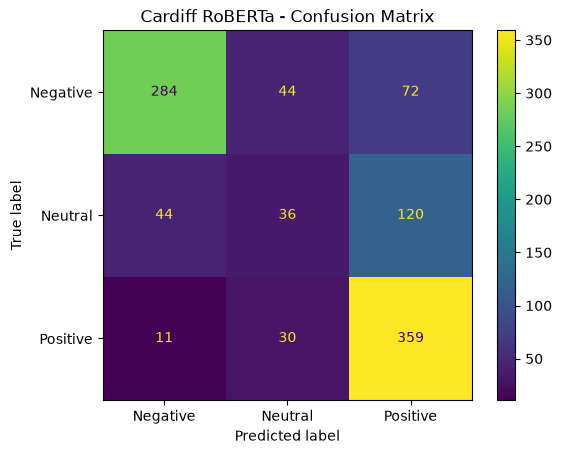

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(values_format="d")
plt.title("Cardiff RoBERTa - Confusion Matrix")
plt.show()

In [26]:
from transformers import pipeline, AutoConfig

smartreview_model = "abhishek1005/smartreview-distilroberta-sentiment"

# Inspect model label configuration first
smartreview_config = AutoConfig.from_pretrained(smartreview_model)

print("Label mapping:")
print(smartreview_config.id2label)

# Load sentiment pipeline
smartreview_classifier = pipeline(
    "sentiment-analysis",
    model=smartreview_model,
    tokenizer=smartreview_model,
    device=-1
)

print("\nSmartReview DistilRoBERTa loaded successfully.")

c:\DATA_SCIENCE\PORTAFOLIO\VibeSig\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MARE\.cache\huggingface\hub\models--abhishek1005--smartreview-distilroberta-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Label mapping:
{0: 'Positive', 1: 'Neutral', 2: 'Negative'}


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 3088.07it/s]



SmartReview DistilRoBERTa loaded successfully.


In [27]:
smartreview_test_results = smartreview_classifier(
    test_reviews["text"].tolist(),
    truncation=True,
    max_length=512
)

for (_, row), result in zip(
    test_reviews.iterrows(),
    smartreview_test_results
):
    print(f"Actual:     {row['actual_sentiment']}")
    print(f"Predicted:  {result['label']}")
    print(f"Confidence: {result['score']:.4f}")
    print(f"Review:     {row['text'][:200]}")
    print("-" * 80)

Actual:     Neutral
Predicted:  Positive
Confidence: 0.9924
Review:     Great food, good service. The crab cakes were solid; not Pacific NW good but still great for the middle of the desert. Portions were large so wishing my wife and and I would have split and entree. The
--------------------------------------------------------------------------------
Actual:     Positive
Predicted:  Positive
Confidence: 0.9983
Review:     Great pizza. If you're sick of those $5 pizza joints, this place has great flavor, a reasonable price and awesome service. Two thumbs way UP! \n\nHungry? Get the Jumbo and watch your mouth drop. \n\nR
--------------------------------------------------------------------------------
Actual:     Positive
Predicted:  Positive
Confidence: 0.9982
Review:     If you want to see the Grand Canyon you should definitely book a tour through Sundance Helicopters! Not only are you delivered to and from your door in a stretch limo, you also get to see all of the V
-----------------

In [28]:
import time

speed_test_df = benchmark_df.head(100)

start_time = time.perf_counter()

smartreview_speed_test = smartreview_classifier(
    speed_test_df["text"].tolist(),
    truncation=True,
    max_length=512,
    batch_size=16
)

smartreview_100_time = time.perf_counter() - start_time

print(f"SmartReview - 100 reviews: {smartreview_100_time:.2f} seconds")
print(f"Average per review: {smartreview_100_time / 100:.4f} seconds")
print(f"Estimated time for 1,000: {smartreview_100_time * 10:.2f} seconds")

SmartReview - 100 reviews: 16.29 seconds
Average per review: 0.1629 seconds
Estimated time for 1,000: 162.86 seconds


In [29]:
import time

start_time = time.perf_counter()

smartreview_results = smartreview_classifier(
    benchmark_df["text"].tolist(),
    truncation=True,
    max_length=512,
    batch_size=16
)

smartreview_time = time.perf_counter() - start_time

benchmark_df["smartreview_prediction"] = [
    result["label"]
    for result in smartreview_results
]

benchmark_df["smartreview_confidence"] = [
    result["score"]
    for result in smartreview_results
]

print(f"SmartReview inference time: {smartreview_time:.2f} seconds")
print(f"Average per review: {smartreview_time / len(benchmark_df):.4f} seconds")

print("\nPredictions:")
print(benchmark_df["smartreview_prediction"].value_counts())

SmartReview inference time: 427.83 seconds
Average per review: 0.4278 seconds

Predictions:
smartreview_prediction
Positive    583
Negative    272
Neutral     145
Name: count, dtype: int64


In [30]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_true = benchmark_df["actual_sentiment"]
y_pred_smartreview = benchmark_df["smartreview_prediction"]

smartreview_accuracy = accuracy_score(
    y_true,
    y_pred_smartreview
)

smartreview_macro_f1 = f1_score(
    y_true,
    y_pred_smartreview,
    average="macro"
)

print(f"Accuracy: {smartreview_accuracy:.4f}")
print(f"Macro F1: {smartreview_macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred_smartreview,
        labels=["Negative", "Neutral", "Positive"],
        digits=4
    )
)

Accuracy: 0.6860
Macro F1: 0.6027

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9338    0.6350    0.7560       400
     Neutral     0.3172    0.2300    0.2667       200
    Positive     0.6621    0.9650    0.7854       400

    accuracy                         0.6860      1000
   macro avg     0.6377    0.6100    0.6027      1000
weighted avg     0.7018    0.6860    0.6699      1000



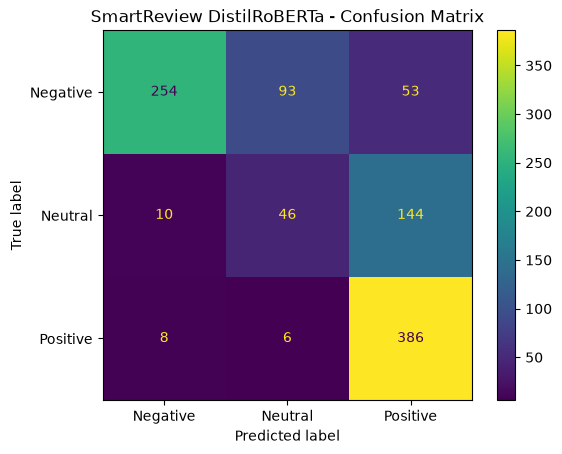

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["Negative", "Neutral", "Positive"]

cm_smartreview = confusion_matrix(
    y_true,
    y_pred_smartreview,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smartreview,
    display_labels=labels
)

disp.plot(values_format="d")
plt.title("SmartReview DistilRoBERTa - Confusion Matrix")
plt.show()

In [32]:
benchmark_df["models_agree"] = (
    benchmark_df["cardiff_prediction"]
    == benchmark_df["smartreview_prediction"]
)

agree_count = benchmark_df["models_agree"].sum()
disagree_count = (~benchmark_df["models_agree"]).sum()

print(f"Models agree:    {agree_count}")
print(f"Models disagree: {disagree_count}")
print(f"Agreement rate:  {agree_count / len(benchmark_df):.2%}")

Models agree:    724
Models disagree: 276
Agreement rate:  72.40%


In [33]:
disagreements_df = benchmark_df[
    benchmark_df["cardiff_prediction"]
    != benchmark_df["smartreview_prediction"]
].copy()

comparison_sample = disagreements_df[
    [
        "rating",
        "actual_sentiment",
        "cardiff_prediction",
        "cardiff_confidence",
        "smartreview_prediction",
        "smartreview_confidence",
        "text"
    ]
].sample(
    n=10,
    random_state=42
)

for _, row in comparison_sample.iterrows():
    print(f"Rating:       {row['rating']} stars")
    print(f"Actual:       {row['actual_sentiment']}")
    print(
        f"Cardiff:      {row['cardiff_prediction']} "
        f"({row['cardiff_confidence']:.4f})"
    )
    print(
        f"SmartReview:  {row['smartreview_prediction']} "
        f"({row['smartreview_confidence']:.4f})"
    )
    print(f"Review:       {row['text'][:500]}")
    print("=" * 100)

Rating:       2 stars
Actual:       Negative
Cardiff:      Negative (0.8723)
SmartReview:  Neutral (0.6704)
Review:       Lot of choice but the shop is kind of oldie inside... I will say is not my favorite shop to spend the night in Vegas.
Rating:       3 stars
Actual:       Neutral
Cardiff:      Neutral (0.4877)
SmartReview:  Negative (0.7802)
Review:       I used to live right across the street from this restaurant but never actually ate there until last night.\n\nMe and a bunch of girls wanted to go out for half price so we gave Mi Ranchito a try. The chips were delicious, the salsa however was EXTREMELY watery. It literally dripped everywhere on the table, making it impossible to actually enjoy. Not that the taste would make you enjoy it...\n\nMe and a friend split a veggie enchilada and another friend shared some of her veggie quasadilla. The e
Rating:       2 stars
Actual:       Negative
Cardiff:      Positive (0.9102)
SmartReview:  Neutral (0.8360)
Review:       Food was good. W

In [34]:
cardiff_correct_disagreements = (
    disagreements_df["cardiff_prediction"]
    == disagreements_df["actual_sentiment"]
).sum()

smartreview_correct_disagreements = (
    disagreements_df["smartreview_prediction"]
    == disagreements_df["actual_sentiment"]
).sum()

print("Among the 276 disagreements:")
print(f"Cardiff correct:      {cardiff_correct_disagreements}")
print(f"SmartReview correct:  {smartreview_correct_disagreements}")

Among the 276 disagreements:
Cardiff correct:      105
SmartReview correct:  112
